In [145]:
# Cell 1: Imports and setup
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / 'data' / 'features'
METADATA_DIR = PROJECT_ROOT / 'data' / 'metadata'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'traditional_ml'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Features dir:', FEATURES_DIR)
print('Out dir:', OUT_DIR)

Project root: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification
Features dir: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\features
Out dir: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\traditional_ml


In [146]:
# Cell 2: Choose which feature set to train on
# Options: 'raw', 'fstat', 'mutual_info', 'random_forest', 'pca'
METHOD = 'pca'

# Sanity: show available files for the chosen method
suffix = '' if METHOD == 'raw' else f'_{METHOD}'
for split in ['train', 'val', 'test']:
    p = FEATURES_DIR / f'features_{split}{suffix}.csv'
    print(split, '->', p.name, '| exists:', p.exists())

train -> features_train_pca.csv | exists: True
val -> features_val_pca.csv | exists: True
test -> features_test_pca.csv | exists: True


In [147]:
# Cell 3: Load data helpers
def load_class_names():
    """Loads the *original* label->name mapping from metadata (may be outdated if you re-indexed labels)."""
    path = METADATA_DIR / 'class_names.json'
    if not path.exists():
        return None
    with path.open('r', encoding='utf-8') as f:
        mapping = json.load(f)
    try:
        items = sorted(((int(k), v) for k, v in mapping.items()), key=lambda kv: kv[0])
        return [v for _, v in items]
    except Exception:
        return list(mapping.values())


def infer_label_name_map_from_image_paths() -> dict[int, str] | None:
    """Infer a robust label->class_name map from `features_train.csv` using image_path folders.

    This fixes the common case where you remove a class folder from splits and re-index labels,
    but forget to update `class_names.json`."""
    raw_path = FEATURES_DIR / 'features_train.csv'
    if not raw_path.exists():
        return None
    df = pd.read_csv(raw_path)
    if 'label' not in df.columns or 'image_path' not in df.columns:
        return None
    # Extract class folder name from image_path (usually parent folder is 'class_XX_...').
    def _extract_class_dir(p: str) -> str:
        try:
            pp = Path(str(p))
            # If path points to the image, parent folder is the class folder.
            return pp.parent.name
        except Exception:
            return ''
    tmp = df[['label', 'image_path']].copy()
    tmp['label'] = tmp['label'].astype(int)
    tmp['class_dir'] = tmp['image_path'].astype(str).map(_extract_class_dir)
    # If parent.name isn't a class dir for some reason, try to find the first segment that starts with 'class_'.
    bad = tmp['class_dir'].str.startswith('class_') == False
    if bad.any():
        def _fallback_find_class_dir(p: str) -> str:
            try:
                parts = Path(str(p)).parts
                for part in parts:
                    if str(part).startswith('class_'):
                        return str(part)
            except Exception:
                pass
            return ''
        tmp.loc[bad, 'class_dir'] = tmp.loc[bad, 'image_path'].astype(str).map(_fallback_find_class_dir)
    tmp = tmp[tmp['class_dir'].str.startswith('class_')]
    if tmp.empty:
        return None
    # Take the most common class_dir per label (mode).
    def _mode(series: pd.Series) -> str:
        vc = series.value_counts()
        return str(vc.index[0]) if len(vc) else ''
    mapping = tmp.groupby('label')['class_dir'].agg(_mode).to_dict()
    # Filter empties
    mapping = {int(k): str(v) for k, v in mapping.items() if str(v)}
    return mapping if mapping else None


def read_features_csv(path: Path):
    df = pd.read_csv(path)
    if 'label' not in df.columns:
        raise ValueError(f"Missing 'label' column in {path}")
    y = df['label'].to_numpy()
    drop_cols = [c for c in ['label', 'image_path'] if c in df.columns]
    X_df = df.drop(columns=drop_cols)
    X = X_df.to_numpy(dtype=np.float64, copy=False)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, y, X_df.columns.tolist()


def load_split(method: str):
    suffix = '' if method == 'raw' else f'_{method}'
    X_train, y_train, cols_train = read_features_csv(FEATURES_DIR / f'features_train{suffix}.csv')
    X_val, y_val, cols_val = read_features_csv(FEATURES_DIR / f'features_val{suffix}.csv')
    X_test, y_test, cols_test = read_features_csv(FEATURES_DIR / f'features_test{suffix}.csv')

    # If you use raw features (unscaled), standardize here for fair comparison
    scaler = None
    if method == 'raw':
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

    # Align columns if needed (should usually match already)
    if cols_train != cols_val or cols_train != cols_test:
        common = [c for c in cols_train if (c in set(cols_val) and c in set(cols_test))]
        if len(common) == 0:
            raise ValueError('No common feature columns across splits; regenerate features.')
        def align(path: Path, common_cols: list[str]):
            df = pd.read_csv(path)
            drop_cols = [c for c in ['label', 'image_path'] if c in df.columns]
            X_df = df.drop(columns=drop_cols)
            X_df = X_df[common_cols]
            X = X_df.to_numpy(dtype=np.float64, copy=False)
            return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X_train = align(FEATURES_DIR / f'features_train{suffix}.csv', common)
        X_val = align(FEATURES_DIR / f'features_val{suffix}.csv', common)
        X_test = align(FEATURES_DIR / f'features_test{suffix}.csv', common)
        cols_train = common
        if method == 'raw':
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
            X_test = scaler.transform(X_test)

    return (X_train, y_train, X_val, y_val, X_test, y_test, cols_train, scaler)


class_names = load_class_names()
label_name_map = infer_label_name_map_from_image_paths()
print('Loaded class_names.json entries:', len(class_names) if class_names else None)
print('Inferred label->name from image_path:', 'OK' if label_name_map else 'None')
if label_name_map:
    print('Inferred mapping:', label_name_map)

Loaded class_names.json entries: 13
Inferred label->name from image_path: OK
Inferred mapping: {0: 'class_01_motorcycle', 1: 'class_02_passenger_car', 2: 'class_03_four_tire_single_unit', 3: 'class_04_bus', 4: 'class_05_two_axle_six_tire_single_unit', 5: 'class_06_three_axle_single_unit', 6: 'class_07_four_or_more_axle_single_unit', 7: 'class_08_four_or_less_axle_single_trailer', 8: 'class_09_five_axle_tractor_semitrailer', 9: 'class_10_six_or_more_axle_single_trailer', 10: 'class_11_five_or_less_axle_multi_trailer', 11: 'class_13_seven_or_more_axle_multi_trailer'}


In [148]:
# Cell 4: Load the chosen dataset
X_train, y_train, X_val, y_val, X_test, y_test, feature_cols, maybe_scaler = load_split(METHOD)

print('Shapes:')
print('  X_train:', X_train.shape, ' y_train:', y_train.shape)
print('  X_val:  ', X_val.shape, ' y_val:  ', y_val.shape)
print('  X_test: ', X_test.shape, ' y_test: ', y_test.shape)

# Label distribution check
labels, counts = np.unique(y_train, return_counts=True)
print('Train label distribution (label: count):')
print(dict(zip(labels.tolist(), counts.tolist())))

# IMPORTANT: your splits may not include every original class id (e.g., you removed a class due to low data).
# After removal, labels are often re-indexed to 0..(K-1). We'll compute what labels actually exist.
LABELS = np.unique(np.concatenate([y_train, y_val, y_test])).astype(int).tolist()

using_inferred = ('label_name_map' in globals()) and bool(label_name_map)

# Prefer the inferred mapping from image_path (correct even if labels were re-indexed).
if using_inferred:
    TARGET_NAMES = [label_name_map.get(i, str(i)) for i in LABELS]
else:
    # Fallback: use class_names.json indexing (only correct if labels were NOT re-indexed).
    if class_names is None:
        TARGET_NAMES = [str(i) for i in LABELS]
    else:
        TARGET_NAMES = [class_names[i] if i < len(class_names) else str(i) for i in LABELS]

print('Active labels in splits:', LABELS)
print('Active class names:', TARGET_NAMES)

# Explain/diagnose mapping vs metadata
if class_names is not None:
    if using_inferred:
        print("\nNOTE: Using inferred label->name mapping from image_path.")
        print("      'class_names.json' may be OUTDATED if you removed/re-indexed classes.")
        print("      Below shows metadata-name vs inferred-name for the labels that exist:\n")
        for lbl in LABELS:
            meta = class_names[lbl] if lbl < len(class_names) else '(out of range)'
            inferred = label_name_map.get(lbl, str(lbl))
            marker = 'OK' if meta == inferred else 'MISMATCH'
            print(f"  label {lbl:2d}: metadata={meta} | inferred={inferred}  [{marker}]")
    else:
        # Only meaningful when labels match metadata indexing
        metadata_ids = list(range(len(class_names)))
        missing_ids = [i for i in metadata_ids if i not in set(LABELS)]
        if len(missing_ids) > 0:
            missing_names = [class_names[i] for i in missing_ids if i < len(class_names)]
            print('Metadata ids missing from splits:', missing_ids)
            print('Metadata names missing from splits:', missing_names)

Shapes:
  X_train: (3909, 2054)  y_train: (3909,)
  X_val:   (285, 2054)  y_val:   (285,)
  X_test:  (297, 2054)  y_test:  (297,)
Train label distribution (label: count):
{0: 199, 1: 527, 2: 423, 3: 182, 4: 220, 5: 329, 6: 252, 7: 372, 8: 440, 9: 352, 10: 252, 11: 361}
Active labels in splits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Active class names: ['class_01_motorcycle', 'class_02_passenger_car', 'class_03_four_tire_single_unit', 'class_04_bus', 'class_05_two_axle_six_tire_single_unit', 'class_06_three_axle_single_unit', 'class_07_four_or_more_axle_single_unit', 'class_08_four_or_less_axle_single_trailer', 'class_09_five_axle_tractor_semitrailer', 'class_10_six_or_more_axle_single_trailer', 'class_11_five_or_less_axle_multi_trailer', 'class_13_seven_or_more_axle_multi_trailer']

NOTE: Using inferred label->name mapping from image_path.
      'class_names.json' may be OUTDATED if you removed/re-indexed classes.
      Below shows metadata-name vs inferred-name for the labels that exi

In [149]:
# Cell 5: Evaluation helpers
def eval_predictions(y_true, y_pred):
    return {
        'acc': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted')),
    }

def train_and_evaluate(name, model):
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_s = time.time() - t0

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    out = {
        'method': METHOD,
        'model': name,
        'n_features': int(X_train.shape[1]),
        'fit_seconds': float(fit_s),
        'train': eval_predictions(y_train, pred_train),
        'val': eval_predictions(y_val, pred_val),
        'test': eval_predictions(y_test, pred_test),
        # Use LABELS/TARGET_NAMES to avoid crashing when some class ids are missing from the splits.
        'test_report': classification_report(
            y_test,
            pred_test,
            labels=LABELS,
            target_names=TARGET_NAMES,
            output_dict=True,
            zero_division=0,
        ),
        'test_confusion_matrix': confusion_matrix(y_test, pred_test, labels=LABELS).tolist(),
        'labels': LABELS,
        'target_names': TARGET_NAMES,
    }

    print('='*70)
    print(f'METHOD={METHOD} | MODEL={name} | FEATURES={X_train.shape[1]} | fit={fit_s:.2f}s')
    print('='*70)
    print('Train:', out['train'])
    print('Val:  ', out['val'])
    print('Test: ', out['test'])
    
    # Print detailed classification report for validation set
    print('\nClassification Report (Validation Set):')
    print('='*70)
    val_report = classification_report(
        y_val,
        pred_val,
        labels=LABELS,
        target_names=TARGET_NAMES,
        zero_division=0,
    )
    print(val_report)
    
    return out

def save_result(result: dict, tag: str | None = None):
    stamp = time.strftime('%Y%m%d_%H%M%S')
    tag_part = f'_{tag}' if tag else ''
    path = OUT_DIR / f"result_{METHOD}_{result['model']}{tag_part}_{stamp}.json"
    with path.open('w', encoding='utf-8') as f:
        json.dump(result, f, indent=2)
    print('Saved:', path)
    return path

# Collect results here as you run models one-by-one
results = []
print('Ready. Run the model cells below one-by-one.')

Ready. Run the model cells below one-by-one.


## Models (run one-by-one)
Run each of the following cells to train a model and append its results to `results`.

In [150]:
# Cell 6: Baseline (most frequent class)
model = DummyClassifier(strategy='most_frequent', random_state=42)
res = train_and_evaluate('dummy_most_frequent', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=dummy_most_frequent | FEATURES=2054 | fit=0.00s
Train: {'acc': 0.13481708876950627, 'f1_macro': 0.019800120228434023, 'f1_weighted': 0.03203273479780424}
Val:   {'acc': 0.4070175438596491, 'f1_macro': 0.04821280133000832, 'f1_weighted': 0.2354814717591985}
Test:  {'acc': 0.4074074074074074, 'f1_macro': 0.048245614035087724, 'f1_weighted': 0.2358674463937622}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       0.00      0.00      0.00        43
                   class_02_passenger_car       0.41      1.00      0.58       116
           class_03_four_tire_single_unit       0.00      0.00      0.00        10
                             class_04_bus       0.00      0.00      0.00        39
   class_05_two_axle_six_tire_single_unit       0.00      0.00      0.00        12
          class_06_three_axle_single_unit       0.00      0.00      0.00        

WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_dummy_most_frequent_20260113_172758.json')

In [151]:
# Cell 7: Logistic Regression
model = LogisticRegression(
    max_iter=5000,
    solver='saga',
    n_jobs=-1,
    random_state=42,
)
res = train_and_evaluate('logreg', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=logreg | FEATURES=2054 | fit=193.13s
Train: {'acc': 0.9997441800972116, 'f1_macro': 0.9996914426470652, 'f1_weighted': 0.9997439489698595}
Val:   {'acc': 0.6842105263157895, 'f1_macro': 0.45265286486182665, 'f1_weighted': 0.6876831863977186}
Test:  {'acc': 0.6767676767676768, 'f1_macro': 0.42461287818430676, 'f1_weighted': 0.6782318946821111}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       0.81      0.81      0.81        43
                   class_02_passenger_car       0.88      0.88      0.88       116
           class_03_four_tire_single_unit       0.33      0.30      0.32        10
                             class_04_bus       0.81      0.67      0.73        39
   class_05_two_axle_six_tire_single_unit       0.08      0.08      0.08        12
          class_06_three_axle_single_unit       0.47      0.50      0.49        18
   class_07_f

WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_logreg_20260113_173112.json')

In [152]:
# Cell 7b: Logistic Regression with Class Balancing (recommended for imbalanced data)
# This addresses the severe class imbalance (class 1: 527 samples vs class 6: 28 samples)
# by weighting loss contributions inversely proportional to class frequencies.
# Expected: F1-macro should improve significantly while test accuracy may drop slightly.
model = LogisticRegression(
    max_iter=5000,
    solver='saga',
    class_weight='balanced',  # KEY: automatically compute weights = n_samples / (n_classes * np.bincount(y))
    n_jobs=-1,
    random_state=42,
)
res = train_and_evaluate('logreg_balanced', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=logreg_balanced | FEATURES=2054 | fit=186.22s
Train: {'acc': 0.9997441800972116, 'f1_macro': 0.999692550529689, 'f1_weighted': 0.9997444090634958}
Val:   {'acc': 0.6842105263157895, 'f1_macro': 0.4560116845362385, 'f1_weighted': 0.6890155585767729}
Test:  {'acc': 0.6666666666666666, 'f1_macro': 0.41517341516829953, 'f1_weighted': 0.6706537716405276}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       0.81      0.81      0.81        43
                   class_02_passenger_car       0.89      0.87      0.88       116
           class_03_four_tire_single_unit       0.33      0.30      0.32        10
                             class_04_bus       0.81      0.67      0.73        39
   class_05_two_axle_six_tire_single_unit       0.08      0.08      0.08        12
          class_06_three_axle_single_unit       0.47      0.50      0.49        18
   cla

WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_logreg_balanced_20260113_173418.json')

In [153]:
# Cell 8: Linear SVM (LinearSVC)
model = LinearSVC(C=1.0, random_state=42)
res = train_and_evaluate('linear_svm', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=linear_svm | FEATURES=2054 | fit=639.98s
Train: {'acc': 0.9997441800972116, 'f1_macro': 0.9996914426470652, 'f1_weighted': 0.9997439489698595}
Val:   {'acc': 0.6105263157894737, 'f1_macro': 0.3655067189669494, 'f1_weighted': 0.6142237365986706}
Test:  {'acc': 0.5925925925925926, 'f1_macro': 0.3201542590153334, 'f1_weighted': 0.588634558268846}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       0.78      0.65      0.71        43
                   class_02_passenger_car       0.82      0.85      0.84       116
           class_03_four_tire_single_unit       0.20      0.30      0.24        10
                             class_04_bus       0.71      0.51      0.60        39
   class_05_two_axle_six_tire_single_unit       0.12      0.08      0.10        12
          class_06_three_axle_single_unit       0.44      0.44      0.44        18
   class_07_

c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_linear_svm_20260113_174458.json')

In [154]:
# Cell 8b: Linear SVM with Class Balancing
# LinearSVC also supports class_weight for handling imbalanced data
model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42,
)
res = train_and_evaluate('linear_svm_balanced', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=linear_svm_balanced | FEATURES=2054 | fit=634.56s
Train: {'acc': 0.9997441800972116, 'f1_macro': 0.999692550529689, 'f1_weighted': 0.9997444090634958}
Val:   {'acc': 0.6175438596491228, 'f1_macro': 0.3779675725509058, 'f1_weighted': 0.6208288819692328}
Test:  {'acc': 0.5858585858585859, 'f1_macro': 0.3276691652239898, 'f1_weighted': 0.582667239560736}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       0.78      0.67      0.72        43
                   class_02_passenger_car       0.81      0.86      0.83       116
           class_03_four_tire_single_unit       0.20      0.30      0.24        10
                             class_04_bus       0.74      0.51      0.61        39
   class_05_two_axle_six_tire_single_unit       0.12      0.08      0.10        12
          class_06_three_axle_single_unit       0.47      0.44      0.46        18
   c

c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_linear_svm_balanced_20260113_175533.json')

In [155]:
# Cell 9: RBF SVM (can be slower)
# If this is too slow, skip it or try smaller C.
model = SVC(C=10.0, kernel='rbf', gamma='scale', random_state=42)
res = train_and_evaluate('rbf_svm', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=rbf_svm | FEATURES=2054 | fit=9.40s
Train: {'acc': 0.9997441800972116, 'f1_macro': 0.9996914426470652, 'f1_weighted': 0.9997439489698595}
Val:   {'acc': 0.6596491228070176, 'f1_macro': 0.40046374759802705, 'f1_weighted': 0.6515324791146442}
Test:  {'acc': 0.6094276094276094, 'f1_macro': 0.3348388697488444, 'f1_weighted': 0.6049801927602411}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       0.91      0.74      0.82        43
                   class_02_passenger_car       0.87      0.84      0.86       116
           class_03_four_tire_single_unit       0.67      0.20      0.31        10
                             class_04_bus       0.53      0.82      0.65        39
   class_05_two_axle_six_tire_single_unit       0.00      0.00      0.00        12
          class_06_three_axle_single_unit       0.50      0.39      0.44        18
   class_07_fou

WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_rbf_svm_20260113_175600.json')

In [156]:
# Cell 10: KNN
model = KNeighborsClassifier(n_neighbors=7, weights='distance')
res = train_and_evaluate('knn_k7', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=knn_k7 | FEATURES=2054 | fit=0.03s
Train: {'acc': 0.9994883601944231, 'f1_macro': 0.9993839967748886, 'f1_weighted': 0.9994883601944231}
Val:   {'acc': 0.41754385964912283, 'f1_macro': 0.26638221828609293, 'f1_weighted': 0.44681801737703286}
Test:  {'acc': 0.42424242424242425, 'f1_macro': 0.28503256003256, 'f1_weighted': 0.4702338813449925}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       0.80      0.19      0.30        43
                   class_02_passenger_car       0.74      0.66      0.69       116
           class_03_four_tire_single_unit       0.50      0.10      0.17        10
                             class_04_bus       0.90      0.23      0.37        39
   class_05_two_axle_six_tire_single_unit       0.00      0.00      0.00        12
          class_06_three_axle_single_unit       1.00      0.22      0.36        18
   class_07_fou

WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_knn_k7_20260113_175601.json')

In [157]:
# Cell 11: Random Forest
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
res = train_and_evaluate('random_forest', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=random_forest | FEATURES=2054 | fit=7.81s
Train: {'acc': 0.9997441800972116, 'f1_macro': 0.9996914426470652, 'f1_weighted': 0.9997439489698595}
Val:   {'acc': 0.47719298245614034, 'f1_macro': 0.20669015482055722, 'f1_weighted': 0.3883571271620841}
Test:  {'acc': 0.5185185185185185, 'f1_macro': 0.2575626121976892, 'f1_weighted': 0.44221844097447555}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       1.00      0.07      0.13        43
                   class_02_passenger_car       0.56      0.96      0.70       116
           class_03_four_tire_single_unit       0.25      0.10      0.14        10
                             class_04_bus       1.00      0.13      0.23        39
   class_05_two_axle_six_tire_single_unit       0.00      0.00      0.00        12
          class_06_three_axle_single_unit       0.50      0.11      0.18        18
   clas

WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_random_forest_20260113_175609.json')

In [158]:
# Cell 12: Gaussian Naive Bayes
model = GaussianNB()
res = train_and_evaluate('gaussian_nb', model)
results.append(res)
save_result(res)

METHOD=pca | MODEL=gaussian_nb | FEATURES=2054 | fit=0.09s
Train: {'acc': 0.5410590943975442, 'f1_macro': 0.5373473076684524, 'f1_weighted': 0.5344643460483289}
Val:   {'acc': 0.11929824561403508, 'f1_macro': 0.08150413429648813, 'f1_weighted': 0.1309087083252632}
Test:  {'acc': 0.09764309764309764, 'f1_macro': 0.06763656102048139, 'f1_weighted': 0.09781175805635514}

Classification Report (Validation Set):
                                           precision    recall  f1-score   support

                      class_01_motorcycle       0.00      0.00      0.00        43
                   class_02_passenger_car       0.93      0.11      0.20       116
           class_03_four_tire_single_unit       1.00      0.10      0.18        10
                             class_04_bus       0.71      0.13      0.22        39
   class_05_two_axle_six_tire_single_unit       0.00      0.00      0.00        12
          class_06_three_axle_single_unit       0.00      0.00      0.00        18
   clas

WindowsPath('c:/Users/amrem/Documents/Engineering Year 4/Machine Learning/Project/Vehicle-Classification/outputs/traditional_ml/result_pca_gaussian_nb_20260113_175610.json')

## Summary
After you run a few models, run the next cells to compare them and save a summary table.

In [159]:
# Cell 13: Build a comparison table
if len(results) == 0:
    raise RuntimeError('No results yet. Run one or more model cells first.')

rows = []
for r in results:
    rows.append({
        'method': r['method'],
        'model': r['model'],
        'n_features': r['n_features'],
        'fit_seconds': r['fit_seconds'],
        'train_acc': r['train']['acc'],
        'val_acc': r['val']['acc'],
        'test_acc': r['test']['acc'],
        'val_f1_macro': r['val']['f1_macro'],
        'test_f1_macro': r['test']['f1_macro'],
    })

df_results = pd.DataFrame(rows).sort_values(['val_acc', 'test_acc'], ascending=False)
df_results.reset_index(drop=True, inplace=True)
df_results

,method,model,n_features,fit_seconds,train_acc,val_acc,test_acc,val_f1_macro,test_f1_macro
0,pca,logreg,2054,193.133424,0.999744,0.684211,0.676768,0.452653,0.424613
1,pca,logreg_balanced,2054,186.219682,0.999744,0.684211,0.666667,0.456012,0.415173
2,pca,rbf_svm,2054,9.399199,0.999744,0.659649,0.609428,0.400464,0.334839
3,pca,linear_svm_balanced,2054,634.560401,0.999744,0.617544,0.585859,0.377968,0.327669
4,pca,linear_svm,2054,639.975863,0.999744,0.610526,0.592593,0.365507,0.320154
5,pca,random_forest,2054,7.814835,0.999744,0.477193,0.518519,0.206690,0.257563
6,pca,knn_k7,2054,0.032186,0.999488,0.417544,0.424242,0.266382,0.285033
7,pca,dummy_most_frequent,2054,0.001000,0.134817,0.407018,0.407407,0.048213,0.048246
8,pca,gaussian_nb,2054,0.089241,0.541059,0.119298,0.097643,0.081504,0.067637


In [160]:
# Cell 14: Save summary CSV
stamp = time.strftime('%Y%m%d_%H%M%S')
out_csv = OUT_DIR / f'summary_{METHOD}_{stamp}.csv'
df_results.to_csv(out_csv, index=False)
print('Saved summary:', out_csv)
df_results.head(10)

Saved summary: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\traditional_ml\summary_pca_20260113_175610.csv


,method,model,n_features,fit_seconds,train_acc,val_acc,test_acc,val_f1_macro,test_f1_macro
0,pca,logreg,2054,193.133424,0.999744,0.684211,0.676768,0.452653,0.424613
1,pca,logreg_balanced,2054,186.219682,0.999744,0.684211,0.666667,0.456012,0.415173
2,pca,rbf_svm,2054,9.399199,0.999744,0.659649,0.609428,0.400464,0.334839
3,pca,linear_svm_balanced,2054,634.560401,0.999744,0.617544,0.585859,0.377968,0.327669
4,pca,linear_svm,2054,639.975863,0.999744,0.610526,0.592593,0.365507,0.320154
5,pca,random_forest,2054,7.814835,0.999744,0.477193,0.518519,0.206690,0.257563
6,pca,knn_k7,2054,0.032186,0.999488,0.417544,0.424242,0.266382,0.285033
7,pca,dummy_most_frequent,2054,0.001000,0.134817,0.407018,0.407407,0.048213,0.048246
8,pca,gaussian_nb,2054,0.089241,0.541059,0.119298,0.097643,0.081504,0.067637


Best by val_acc: {'method': 'pca', 'model': 'logreg', 'n_features': 2054, 'fit_seconds': 193.1334240436554, 'train_acc': 0.9997441800972116, 'val_acc': 0.6842105263157895, 'test_acc': 0.6767676767676768, 'val_f1_macro': 0.45265286486182665, 'test_f1_macro': 0.42461287818430676}


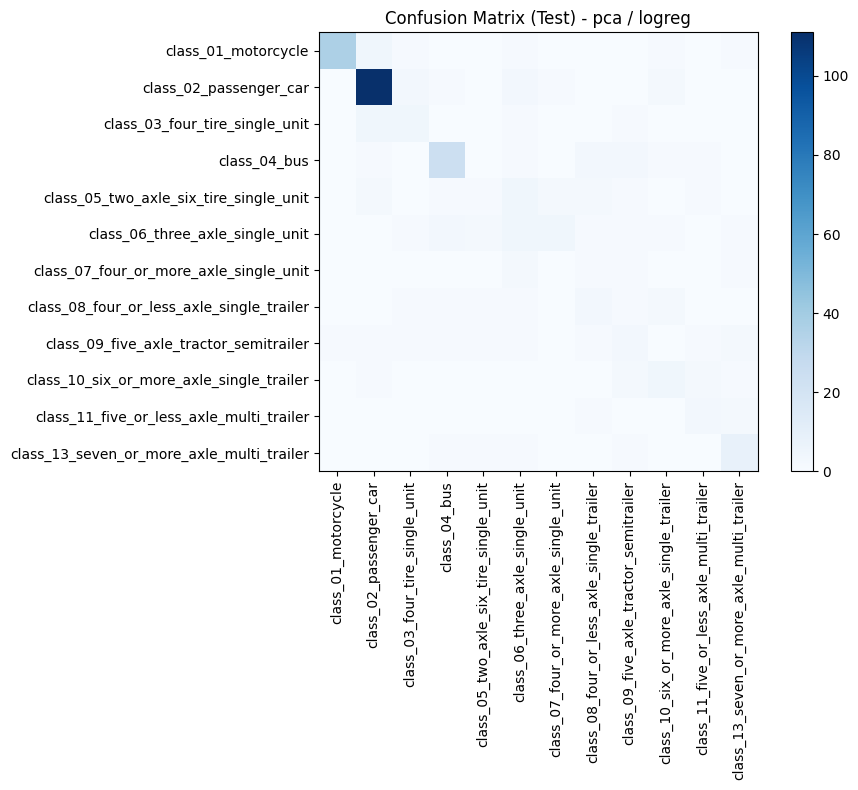

In [161]:
# Cell 15: Confusion matrix for the current best model (by val_acc)
best = df_results.iloc[0]
best_name = best['model']
print('Best by val_acc:', best.to_dict())

# Find the full stored result
best_res = None
for r in results:
    if r['model'] == best_name:
        best_res = r
        break

if best_res is None:
    raise RuntimeError('Could not find best model result in results list.')

cm = np.array(best_res['test_confusion_matrix'])
labels_used = best_res.get('labels', LABELS)
names_used = best_res.get('target_names', TARGET_NAMES)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'Confusion Matrix (Test) - {METHOD} / {best_name}')
plt.colorbar()

ticks = np.arange(len(labels_used))
plt.xticks(ticks, names_used, rotation=90)
plt.yticks(ticks, names_used)

plt.tight_layout()
plt.show()